In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nAttrition value counts:\n", df['Attrition'].value_counts())

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber          

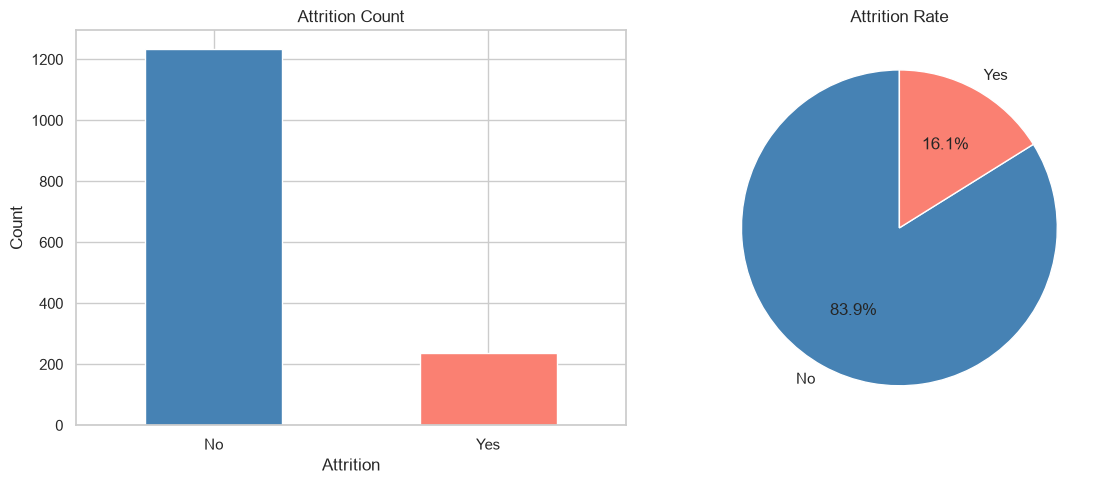

Attrition rate: 16.1 %


In [2]:
# Set style
sns.set_theme(style="whitegrid")

# 1. Overall attrition rate bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['Attrition'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Percentage pie chart
df['Attrition'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Attrition Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../screenshots/attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attrition rate:", round(237/1470*100, 1), "%")

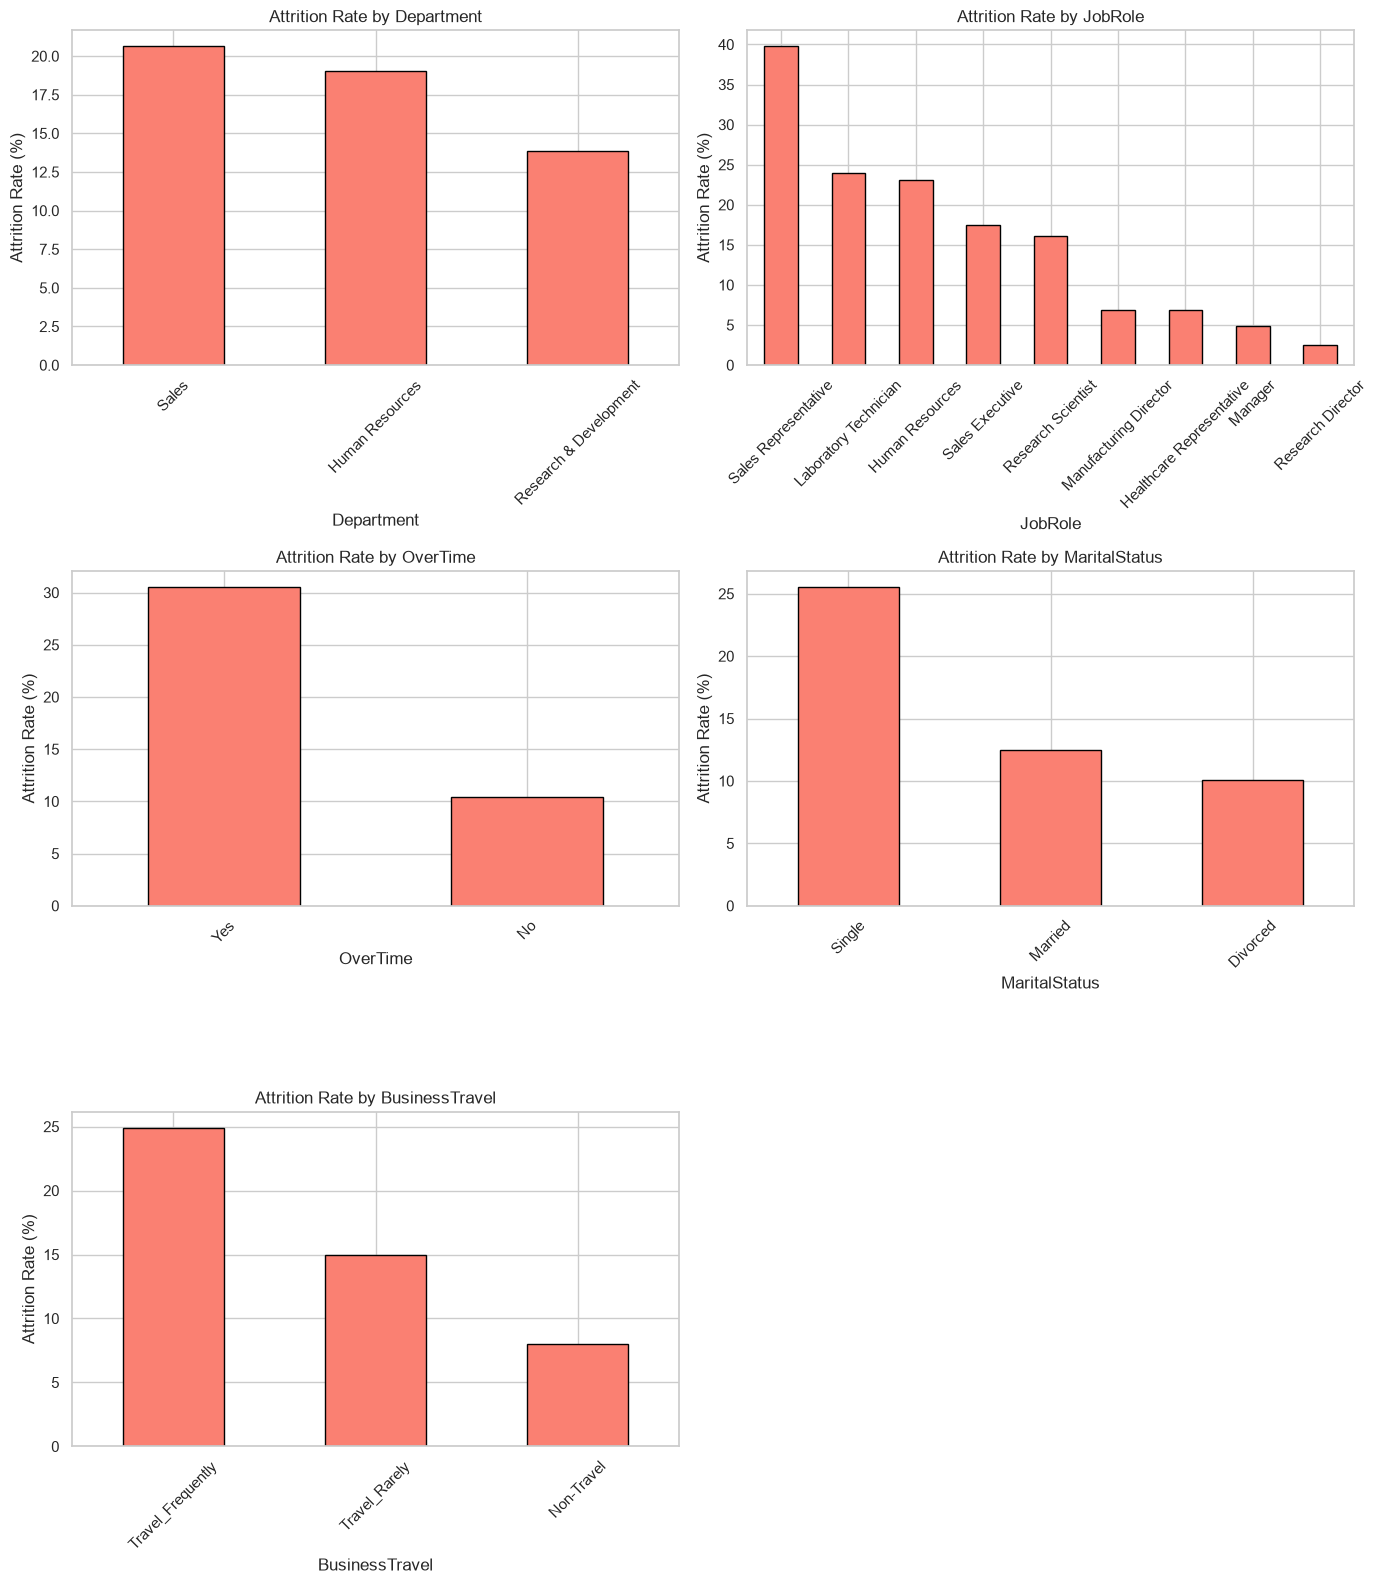

In [3]:
# Attrition rate by key categorical features
cat_cols = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    attrition_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Attrition Rate by {col}')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

# Hide the last empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('../screenshots/attrition_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Attrition rates by Job Satisfaction and Work-Life Balance:
SatisfactionGroup  WLBGroup
High Satisfaction  High WLB    11.9
                   Low WLB     18.5
Low Satisfaction   High WLB    19.0
                   Low WLB     21.4
Name: Attrition, dtype: float64



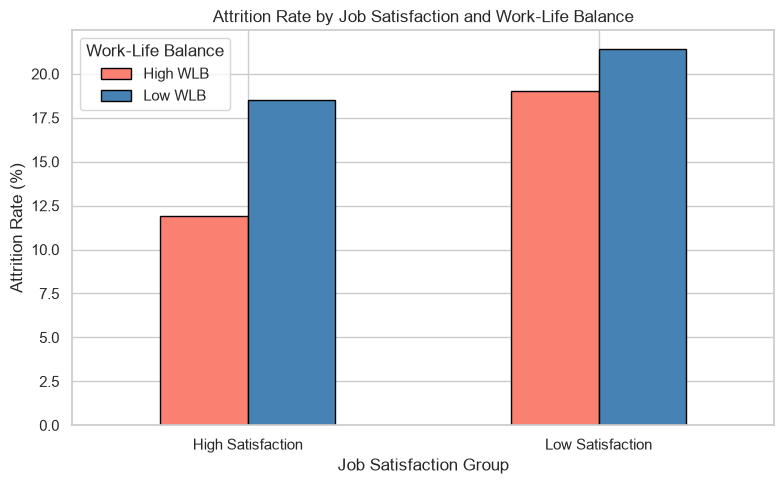

In [4]:
# Hypothesis: Work-life balance is an independent attrition driver
# Compare attrition rates across JobSatisfaction and WorkLifeBalance combinations

# High satisfaction = 3 or 4, Low satisfaction = 1 or 2
# Low work-life balance = 1 or 2, High work-life balance = 3 or 4

df['SatisfactionGroup'] = df['JobSatisfaction'].apply(
    lambda x: 'High Satisfaction' if x >= 3 else 'Low Satisfaction'
)
df['WLBGroup'] = df['WorkLifeBalance'].apply(
    lambda x: 'Low WLB' if x <= 2 else 'High WLB'
)

# Attrition rate by group combination
groups = df.groupby(['SatisfactionGroup', 'WLBGroup'])['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print("Attrition rates by Job Satisfaction and Work-Life Balance:")
print(groups)
print()

# Visualize
pivot = df.pivot_table(
    values='Attrition',
    index='SatisfactionGroup',
    columns='WLBGroup',
    aggfunc=lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='black')
ax.set_title('Attrition Rate by Job Satisfaction and Work-Life Balance')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Job Satisfaction Group')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Work-Life Balance')

plt.tight_layout()
plt.savefig('../screenshots/hypothesis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()